**An analysis of NYC Department of Health and Mental Hygiene's response to  311 Service Request - Jan 2023 - August 2026 **

Is the NYC DOHMH closing Service Requests in an appropiate time?

In [1]:
from google.colab import files
uploaded = files.upload()


Saving 311_Service_Requests_from_2020_to_Present_20260916.csv to 311_Service_Requests_from_2020_to_Present_20260916.csv


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/311_Service_Requests_from_2020_to_Present_20260916.csv')

Sneak peek at what's in the database - columns and datatypes to see what I need and how much cleaning needs to be done

In [6]:
df

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,70256679,08/31/2026 10:10:48 PM,NaN,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Food Contaminated,Other Contaminant in Food,Restaurant/Bar/Deli/Bakery,10001.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.747085,-73.993457,POINT (-73.993456881291 40.747085242222)
1,70250692,08/31/2026 10:04:08 PM,NaN,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Bare Hands in Contact w/ Food,NaN,Restaurant/Bar/Deli/Bakery,10462.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.836199,-73.853658,POINT (-73.853657684392 40.83619906359)
2,70261211,08/31/2026 09:41:10 PM,NaN,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Rodents/Insects/Garbage,Rodent Infestation,Restaurant/Bar/Deli/Bakery,11369.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.760048,-73.878349,POINT (-73.878349350239 40.760047763665)
3,70259735,08/31/2026 09:13:43 PM,NaN,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Rodents/Insects/Garbage,Insect Infestation,Restaurant/Bar/Deli/Bakery,11220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.635916,-74.010272,POINT (-74.010272120776 40.635916340805)
4,70253628,08/31/2026 08:49:57 PM,NaN,DOHMH,Department of Health and Mental Hygiene,Food Establishment,No Permit or License,NaN,Restaurant/Bar/Deli/Bakery,10039.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.826724,-73.939090,POINT (-73.939090253234 40.826724219861)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52078,56413340,01/01/2023 08:04:32 AM,06/03/2024 10:59:14 PM,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Rodents/Insects/Garbage,Garbage Improperly Stored,Restaurant/Bar/Deli/Bakery,10014.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.735242,-74.006062,POINT (-74.006062043889 40.735241667425)
52079,56418777,01/01/2023 03:38:41 AM,06/03/2024 10:59:12 PM,DOHMH,Department of Health and Mental Hygiene,Food Establishment,No Permit or License,NaN,Restaurant/Bar/Deli/Bakery,11221.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.685008,-73.929484,POINT (-73.929484468155 40.685007533519)
52080,56412756,01/01/2023 02:50:56 AM,06/03/2024 10:59:11 PM,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Rodents/Insects/Garbage,Rodent Infestation,Restaurant/Bar/Deli/Bakery,11105.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.774785,-73.908777,POINT (-73.908777036533 40.774784949537)
52081,56418387,01/01/2023 12:44:26 AM,06/03/2024 10:59:10 PM,DOHMH,Department of Health and Mental Hygiene,Food Establishment,Rodents/Insects/Garbage,Insect Infestation,Restaurant/Bar/Deli/Bakery,11234.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.634066,-73.919483,POINT (-73.919482629924 40.634066069356)


In [7]:
df.dtypes

,0
Unique Key,int64
Created Date,object
Closed Date,object
Agency,object
Agency Name,object
Problem (formerly Complaint Type),object
Problem Detail (formerly Descriptor),object
Additional Details,object
Location Type,object
Incident Zip,float64


Because it 44 columns, i will see which columns i need.I will create a new  dataframe (df2) with the necessary columns


In [8]:
df.columns


Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Problem (formerly Complaint Type)',
       'Problem Detail (formerly Descriptor)', 'Additional Details',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Cross Street 1', 'Cross Street 2', 'Intersection Street 1',
       'Intersection Street 2', 'Address Type', 'City', 'Landmark',
       'Facility Type', 'Status', 'Due Date', 'Resolution Description',
       'Resolution Action Updated Date', 'Community Board', 'Council District',
       'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Open Data Channel Type',
       'Park Facility Name', 'Park Borough', 'Vehicle Type',
       'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name',
       'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment',
       'Latitude', 'Longitude', 'Location'],
      dtype='object')

opted to create df2 by listing the columns rather than using the drop columns function

In [9]:
df2 = df[['Unique Key', 'Created Date', 'Closed Date',
       'Additional Details','Status','Resolution Description','Resolution Action Updated Date','Borough']].copy()

exploring the new datframe. its way more manageable and easier to read since i can see everything (all columns at once)

In [10]:
df2

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique Key,Created Date,Closed Date,Additional Details,Status,Resolution Description,Resolution Action Updated Date,Borough
0,70256679,08/31/2026 10:10:48 PM,NaN,Other Contaminant in Food,In Progress,The Department of Health and Mental Hygiene ha...,09/09/2026 09:51:29 AM,MANHATTAN
1,70250692,08/31/2026 10:04:08 PM,NaN,NaN,In Progress,NaN,NaN,BRONX
2,70261211,08/31/2026 09:41:10 PM,NaN,Rodent Infestation,In Progress,The Department of Health and Mental Hygiene ha...,08/31/2026 09:41:18 PM,QUEENS
3,70259735,08/31/2026 09:13:43 PM,NaN,Insect Infestation,In Progress,The Department of Health and Mental Hygiene ha...,09/09/2026 09:51:29 AM,BROOKLYN
4,70253628,08/31/2026 08:49:57 PM,NaN,NaN,In Progress,NaN,NaN,MANHATTAN
...,...,...,...,...,...,...,...,...
52078,56413340,01/01/2023 08:04:32 AM,06/03/2024 10:59:14 PM,Garbage Improperly Stored,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:17 PM,MANHATTAN
52079,56418777,01/01/2023 03:38:41 AM,06/03/2024 10:59:12 PM,NaN,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:15 PM,BROOKLYN
52080,56412756,01/01/2023 02:50:56 AM,06/03/2024 10:59:11 PM,Rodent Infestation,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:15 PM,QUEENS
52081,56418387,01/01/2023 12:44:26 AM,06/03/2024 10:59:10 PM,Insect Infestation,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:13 PM,BROOKLYN


checking for any missing values -- missing values in closed date indicates its not closed yet, so i can work with everything. YAY!!!

In [11]:
df2.isnull().sum()

,0
Unique Key,0
Created Date,0
Closed Date,2377
Additional Details,16237
Status,0
Resolution Description,631
Resolution Action Updated Date,625
Borough,0


In [ ]:
another check of datatype of each column

In [12]:
df2.dtypes

,0
Unique Key,int64
Created Date,object
Closed Date,object
Additional Details,object
Status,object
Resolution Description,object
Resolution Action Updated Date,object
Borough,object


because the created date and closed date are objects i need to convert it to datetime format.     

In [13]:
df2['Created Date'] = pd.to_datetime(df2['Created Date'])

/tmp/ipykernel_3395/3361517875.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['Created Date'] = pd.to_datetime(df2['Created Date'])


In [14]:
df2['Closed Date'] = pd.to_datetime(df2['Closed Date'])

/tmp/ipykernel_3395/3635967719.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['Closed Date'] = pd.to_datetime(df2['Closed Date'])


successful conversion

In [15]:
dtypes = df2.dtypes
print(dtypes)

Unique Key                                 int64
Created Date                      datetime64[ns]
Closed Date                       datetime64[ns]
Additional Details                        object
Status                                    object
Resolution Description                    object
Resolution Action Updated Date            object
Borough                                   object
dtype: object


In [16]:
import numpy as np

In [17]:
df2['days_between'] = (df2['Closed Date'] - df2['Created Date']).dt.days

In [18]:
#df2['days_between'] = (df2['Closed Date'] - df2['Created Date']) / np.timedelta64(1, 'D')

Now I have a new column called "days_between"  that counts the days it takes between creating and closing  

In [19]:
df2

,Unique Key,Created Date,Closed Date,Additional Details,Status,Resolution Description,Resolution Action Updated Date,Borough,days_between
0,70256679,2026-08-31 22:10:48,NaT,Other Contaminant in Food,In Progress,The Department of Health and Mental Hygiene ha...,09/09/2026 09:51:29 AM,MANHATTAN,NaN
1,70250692,2026-08-31 22:04:08,NaT,NaN,In Progress,NaN,NaN,BRONX,NaN
2,70261211,2026-08-31 21:41:10,NaT,Rodent Infestation,In Progress,The Department of Health and Mental Hygiene ha...,08/31/2026 09:41:18 PM,QUEENS,NaN
3,70259735,2026-08-31 21:13:43,NaT,Insect Infestation,In Progress,The Department of Health and Mental Hygiene ha...,09/09/2026 09:51:29 AM,BROOKLYN,NaN
4,70253628,2026-08-31 20:49:57,NaT,NaN,In Progress,NaN,NaN,MANHATTAN,NaN
...,...,...,...,...,...,...,...,...,...
52078,56413340,2023-01-01 08:04:32,2024-06-03 22:59:14,Garbage Improperly Stored,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:17 PM,MANHATTAN,519.0
52079,56418777,2023-01-01 03:38:41,2024-06-03 22:59:12,NaN,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:15 PM,BROOKLYN,519.0
52080,56412756,2023-01-01 02:50:56,2024-06-03 22:59:11,Rodent Infestation,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:15 PM,QUEENS,519.0
52081,56418387,2023-01-01 00:44:26,2024-06-03 22:59:10,Insect Infestation,Closed,This SR was administratively closed. The issue...,06/03/2024 10:59:13 PM,BROOKLYN,519.0


sorting to from longest closing time to shortest

In [20]:
df2.sort_values(by='days_between', ascending=False)

,Unique Key,Created Date,Closed Date,Additional Details,Status,Resolution Description,Resolution Action Updated Date,Borough,days_between
37597,60306840,2024-02-12 00:00:00,2026-02-27 10:56:32,NaN,Closed,The condition you reported was investigated. ...,02/27/2026 10:56:32 AM,BROOKLYN,746.0
37532,60325814,2024-02-14 00:00:00,2026-02-20 13:39:51,NaN,Closed,The Department of Health and Mental Hygiene ha...,02/20/2026 01:39:51 PM,QUEENS,737.0
36886,60493198,2024-03-04 00:00:00,2026-02-27 10:51:49,NaN,Closed,The condition you reported was investigated. ...,02/27/2026 10:51:49 AM,MANHATTAN,725.0
50237,56868885,2023-02-22 20:00:57,2025-01-11 20:24:34,NaN,Closed,The NYC Health Department has responded to you...,01/11/2025 08:24:37 PM,MANHATTAN,689.0
31752,61758490,2024-07-10 00:00:00,2026-03-03 10:48:53,NaN,Closed,The condition you reported was investigated. ...,03/03/2026 10:48:53 AM,MANHATTAN,601.0
...,...,...,...,...,...,...,...,...,...
52070,56416389,2023-01-01 12:08:31,NaT,NaN,In Progress,NaN,NaN,MANHATTAN,NaN
52071,56418094,2023-01-01 11:19:40,NaT,NaN,In Progress,NaN,NaN,BRONX,NaN
52072,56418211,2023-01-01 11:10:08,NaT,NaN,In Progress,NaN,NaN,MANHATTAN,NaN
52075,56413642,2023-01-01 09:41:28,NaT,NaN,In Progress,NaN,NaN,MANHATTAN,NaN


getting the descriptive statistics on the dataframe


In [21]:
df2.describe()

,Unique Key,Created Date,Closed Date,days_between
count,5.208300e+04,52083,49706,49706.000000
mean,6.329269e+07,2024-11-24 20:43:02.480943872,2025-03-15 14:09:21.871685632,132.226210
min,5.641276e+07,2023-01-01 00:00:00,2023-01-03 00:00:01,0.000000
25%,5.987762e+07,2023-12-29 13:40:42,2024-06-04 02:13:51.249999872,59.000000
50%,6.320688e+07,2024-11-25 16:36:59,2025-01-11 17:48:32,60.000000
75%,6.661280e+07,2025-10-25 20:48:37,2025-11-20 09:27:55.750000128,205.000000
max,7.026122e+07,2026-08-31 22:10:48,2026-09-15 01:35:08,746.000000
std,4.024101e+06,NaN,NaN,131.517342


filtering to count the top specific complaint types and importing mathplotlib to execute. i added seaborn to do somethings else but didnt use it

In [22]:
df2.groupby('Additional Details')['Unique Key'].count().sort_values(ascending=False).head(20)

,Unique Key
Additional Details,
Rodent Infestation,7622
Pet or Bird Present,3829
Food Spoiled,3180
Insect Infestation,2900
Letter Grade Missing/Not Visible,2663
Other Contaminant in Food,1997
Garbage Improperly Stored,1913
Condition Attracting Vermin,1227
No Toilet Facility,1122


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [24]:
details_counts = df2.groupby('Additional Details')['Unique Key'].count().sort_values(ascending=False).head(20)
fig = px.treemap(details_counts.reset_index(name='ComplaintCount'), path=['Additional Details'], values='ComplaintCount', title='Top 20 Complaints')
fig.show()

grouping by status to see how  many complaints are open vs closed and making a pie chart to show this

In [25]:
df2.groupby('Status')['Unique Key'].count().sort_values(ascending=False).head(50)

,Unique Key
Status,
Closed,49705
In Progress,2377
Unspecified,1


<Axes: title={'center': 'Complaint Status'}>

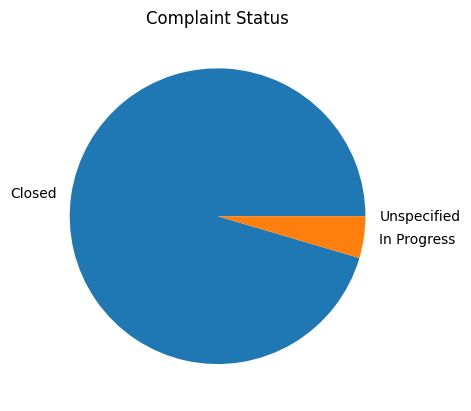

In [26]:
df2.groupby('Status')['Unique Key'].count().sort_values(ascending=False).plot(kind='pie', ylabel='', title='Complaint Status')

group by resolution to see the most commmon resolution response

In [27]:
df2.groupby('Resolution Description')['Unique Key'].count().sort_values(ascending=False).head(5)

,Unique Key
Resolution Description,
The NYC Health Department has responded to your service request. Restaurant inspection information can be found online at www.nyc.gov/health/abceats. This service request has been closed.,26984
This SR was administratively closed. The issue you reported was addressed.,13378
The Department of Health and Mental Hygiene has determined that the reported incident is isolated. The establishment will be inspected according to its normal schedule for sanitary inspections.,5464
The Health Departmentâs Office of Environmental Investigations has determined this case was an isolated incident. The Departmentâs Bureau of Food Safety and Community Sanitation will review to see if a sanitary inspection is necessary. All food establishments are inspected annually. You can get results of all food safety inspections by going online to www.nyc.gov/health/restaurants.,1987
"The Department of Health and Mental Hygiene has sent official written notification to the Owner/Landlord warning them of potential violations and instructing them to correct the situation. If the situation persists 21 days after your initial complaint, please make a new complaint.",1471


from above ^^ we see that resolution #1 and #4 send customers to the department's public website so analysing this would be difficult because youd have to manually count those responses or reclassify them as the same

In [28]:
details_counts = df2.groupby('Resolution Description')['Unique Key'].count().sort_values(ascending=False).head(5)
fig = px.treemap(details_counts.reset_index(name='ComplaintCount'), path=['Resolution Description'], values='ComplaintCount', title='Top 5 Responses')
fig.show()

In [ ]:
didnt use top 5

In [29]:
details_counts = df2.groupby('Additional Details')['Unique Key'].count().sort_values(ascending=False).head(20)
fig = px.treemap(details_counts.reset_index(name='ComplaintCount'), path=['Additional Details'], values='ComplaintCount', title='Top 20 Complaints')
fig.show()

counting by borough, normalized then creating pie chart to represent it

In [32]:
df2.groupby('Borough')['Unique Key'].count()

,Unique Key
Borough,
BRONX,4484
BROOKLYN,14560
MANHATTAN,19669
QUEENS,11256
STATEN ISLAND,1520
Unspecified,594


<Axes: title={'center': 'Distirbution of complaints across boroughs'}>

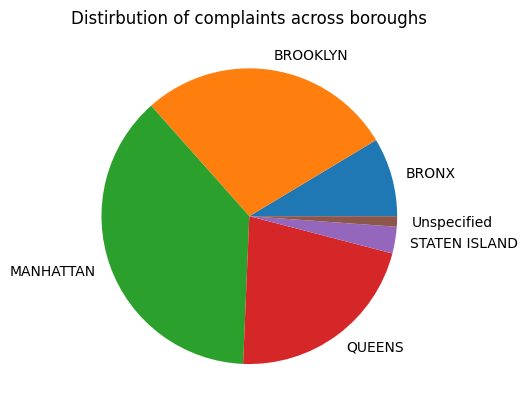

In [43]:
df2.groupby('Borough')['Unique Key'].count().plot(kind='pie', title="Distirbution of complaints across boroughs", ylabel='', )

In [30]:
df2['Borough'].value_counts(normalize=True)


,proportion
Borough,
MANHATTAN,0.377647
BROOKLYN,0.279554
QUEENS,0.216117
BRONX,0.086093
STATEN ISLAND,0.029184
Unspecified,0.011405


<Axes: title={'center': 'Distirbution of complaints across boroughs'}>

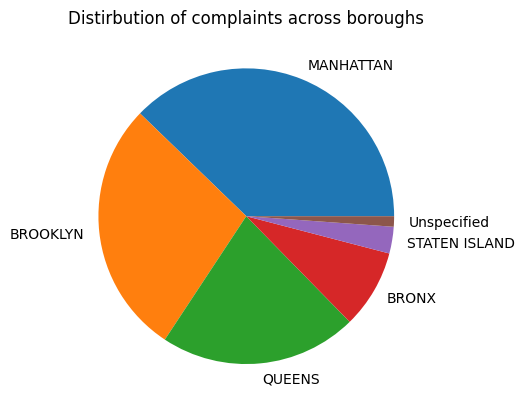

In [31]:
df2['Borough'].value_counts(normalize=True).plot(kind='pie', title="Distirbution of complaints across boroughs", ylabel='', )

finding the mean days to resolve by year

In [33]:
df2.groupby(df2['Created Date'].dt.year)['days_between'].mean()

,days_between
Created Date,
2023,282.017937
2024,123.670671
2025,55.016276
2026,48.263778


descriptive statistics by year - but i removed percentile because i didnt need that on the graph

In [34]:
df2.groupby(df2['Created Date'].dt.year)['days_between'].describe(percentiles=[])

,count,mean,std,min,50%,max
Created Date,,,,,,
2023,12934.0,282.017937,154.753897,0.0,302.0,689.0
2024,13986.0,123.670671,79.936859,0.0,116.5,746.0
2025,14131.0,55.016276,37.809584,0.0,60.0,422.0
2026,8655.0,48.263778,21.390486,0.0,60.0,237.0


same as above

In [35]:
df2.groupby(df2['Created Date'].dt.year)['days_between'].describe(percentiles=[])

,count,mean,std,min,50%,max
Created Date,,,,,,
2023,12934.0,282.017937,154.753897,0.0,302.0,689.0
2024,13986.0,123.670671,79.936859,0.0,116.5,746.0
2025,14131.0,55.016276,37.809584,0.0,60.0,422.0
2026,8655.0,48.263778,21.390486,0.0,60.0,237.0


didn't use this sunbust but i was testing another plotly graph. I couldn't figure out how to use it how i want to but i got it to work in this way. i didnt need this visualization

In [36]:
df2['Creation_Year'] = df2['Created Date'].dt.year
df2.groupby(df2['Created Date'].dt.year)['days_between'].describe(percentiles=[])
fig = px.sunburst(df2, path=['Creation_Year', 'Borough'], values='Unique Key', title='Complaints by Creation Year and Borough')
fig.show()

In [37]:
import matplotlib.pyplot as plt

[Text(0, 0, '12934'),
 Text(0, 0, '13986'),
 Text(0, 0, '14131'),
 Text(0, 0, '8655')]

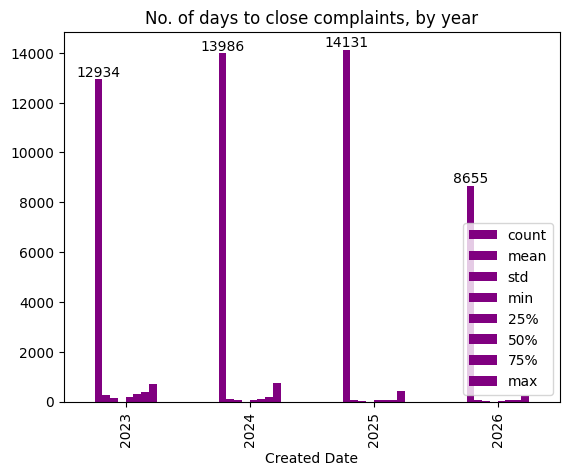

In [38]:
ax = df2.groupby(df2['Created Date'].dt.year)['days_between'].describe().plot(kind='bar', title='No. of days to close complaints, by year', color='purple')
ax.bar_label(ax.containers[0])

created a graph of all of the descriptive but the very high count made it hard to see the lower values so i put the count in a graph of it own

<Axes: title={'center': 'No. of complaints over the years'}, xlabel='Created Date'>

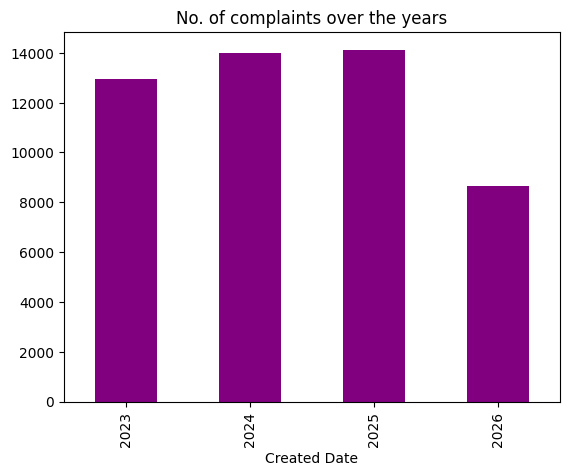

In [39]:
customcolor = ['purple']
df2.groupby(df2['Created Date'].dt.year)['days_between'].describe(percentiles=[]).drop(columns=['mean','max','min','50%','std']).plot(kind='bar', color=customcolor,title='No. of complaints over the years', legend=False )

graph of count only.
i used the describe function then drop columns but i could've simply do .mean  

<Axes: title={'center': 'Comparing the time it takes to close complaints over the years'}, xlabel='Created Date'>

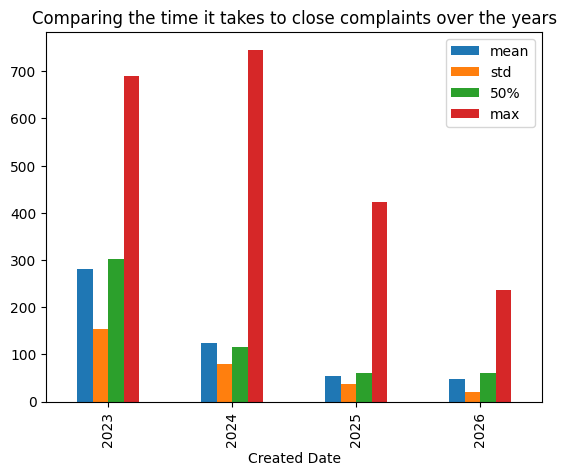

In [40]:
df2.groupby(df2['Created Date'].dt.year)['days_between'].describe(percentiles=[]).drop(columns=['count','min']).plot(kind='bar', title='Comparing the time it takes to close complaints over the years' )

graph of everything except very high max

<Axes: xlabel='Created Date'>

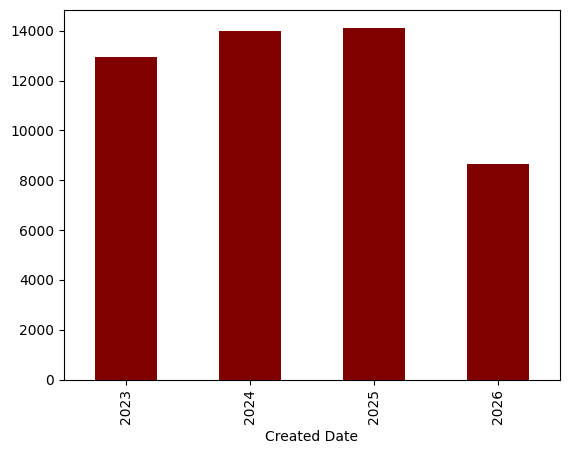

In [41]:
df2.groupby(df2['Created Date'].dt.year)['days_between'].count().plot(kind='bar', color='maroon')

– – Include a research question – what is the goal of your analysis/project? What
are you trying to understand?
– Descriptive and inferential statistics regarding the data in your dataset.
– Data cleaning/transformations.
– Data visualizations to support your findings.
– A conclusion relevant to your analysis.




**Conclusion **

52,082 complaints in the 3yrs, 8 months study period.
max time, mean and median time close complaints are trending downwards
number of complaint received by year is trending upwards (steadily)
complaints are being answered within the alotted time based on the Service Level Agreement ?

Research question, Is the NYC DOHMH closing Service Requests in an appropiate time? Based on analysis, rensposes are done in a timely manner.

future study

this analysis stopped at the end of August and the amount of complaints are lower than expected (if it is to meet the expected 13500 by year end) so i assume that the busy complain months are end of year. Another study can be with this as the hypothesis.

the min was 0 so i took that out. A further analysis to analyse using data where min of 0 (automatically closed) is excluded to see how the values change when complaints arent answered automatically

**THE END**


